       RETAIL SALES DATA ANALYZER


Enter CSV file path (default: retail_sales.csv):  C:\Users\rnw\Downloads\retail_sales_project\retail_sales.csv


Data loaded successfully: 15 rows.

========== RETAIL SALES SUMMARY ==========
Total Sales       : ₹1,223,000.00
Average Sale/Row  : ₹81,533.33
Total Quantity    : 100
Most Popular      : Headphones (37 units)
Average Growth    : 26.25%


---------- MENU ----------
1. Display summary
2. Filter by category
3. Filter by date range
4. Show visualizations
5. Show cleaned data
6. Exit


Enter your choice:  1



========== RETAIL SALES SUMMARY ==========
Total Sales       : ₹1,223,000.00
Average Sale/Row  : ₹81,533.33
Total Quantity    : 100
Most Popular      : Headphones (37 units)
Average Growth    : 26.25%


---------- MENU ----------
1. Display summary
2. Filter by category
3. Filter by date range
4. Show visualizations
5. Show cleaned data
6. Exit


...

Enter your choice:  2
Enter category (e.g. Electronics/Furniture):  Furniture


      Date Product  Category  Price  Quantity Sold  Total Sales
2026-01-15   Chair Furniture   4500              6        27000
2026-01-20   Table Furniture   8000              3        24000
2026-02-18   Chair Furniture   4500              8        36000
2026-02-25   Table Furniture   8000              4        32000
2026-03-16   Chair Furniture   4500             10        45000
2026-03-22   Table Furniture   8000              5        40000

---------- MENU ----------
1. Display summary
2. Filter by category
3. Filter by date range
4. Show visualizations
5. Show cleaned data
6. Exit


Enter your choice:  3
Enter start date (YYYY-MM-DD):  2026-01-25
Enter end date (YYYY-MM-DD):  2026-03-22


      Date    Product    Category  Price  Quantity Sold  Total Sales
2026-02-03     Laptop Electronics  55000              3       165000
2026-02-07      Phone Electronics  25000              7       175000
2026-02-11 Headphones Electronics   2000             15        30000
2026-02-18      Chair   Furniture   4500              8        36000
2026-02-25      Table   Furniture   8000              4        32000
2026-03-02     Laptop Electronics  55000              4       220000
2026-03-06      Phone Electronics  25000              6       150000
2026-03-10 Headphones Electronics   2000             12        24000
2026-03-16      Chair   Furniture   4500             10        45000
2026-03-22      Table   Furniture   8000              5        40000

---------- MENU ----------
1. Display summary
2. Filter by category
3. Filter by date range
4. Show visualizations
5. Show cleaned data
6. Exit


Enter your choice:  4


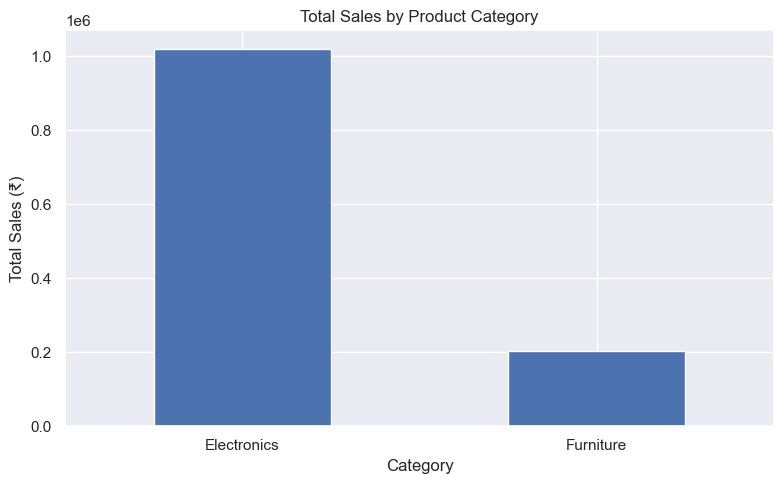

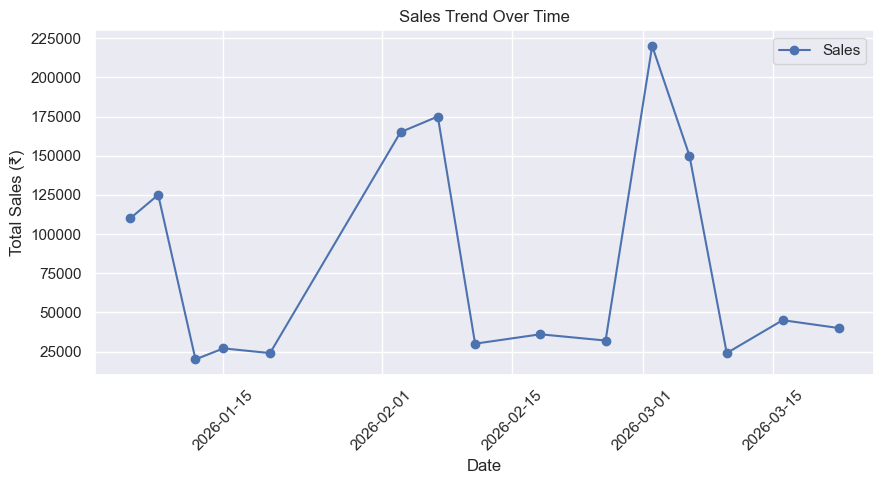

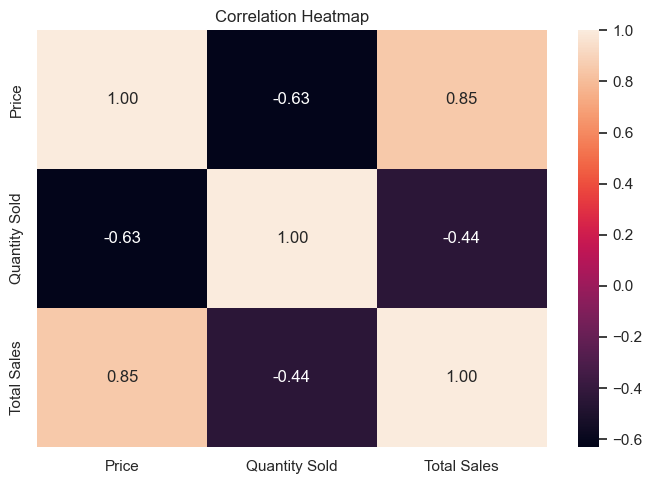


---------- MENU ----------
1. Display summary
2. Filter by category
3. Filter by date range
4. Show visualizations
5. Show cleaned data
6. Exit


Enter your choice:  5


      Date    Product    Category  Price  Quantity Sold  Total Sales
2026-01-05     Laptop Electronics  55000              2       110000
2026-01-08      Phone Electronics  25000              5       125000
2026-01-12 Headphones Electronics   2000             10        20000
2026-01-15      Chair   Furniture   4500              6        27000
2026-01-20      Table   Furniture   8000              3        24000
2026-02-03     Laptop Electronics  55000              3       165000
2026-02-07      Phone Electronics  25000              7       175000
2026-02-11 Headphones Electronics   2000             15        30000
2026-02-18      Chair   Furniture   4500              8        36000
2026-02-25      Table   Furniture   8000              4        32000
2026-03-02     Laptop Electronics  55000              4       220000
2026-03-06      Phone Electronics  25000              6       150000
2026-03-10 Headphones Electronics   2000             12        24000
2026-03-16      Chair   Furniture 

Enter your choice:  6


Thank you for using Retail Sales Data Analyzer.


In [5]:
### import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class RetailAnalyzer:
    """Retail sales data analyzer using Pandas, NumPy, Matplotlib and Seaborn."""

    REQUIRED_COLUMNS = [
        "Date", "Product", "Category",
        "Price", "Quantity Sold", "Total Sales"
    ]

    def __init__(self):
        self.data = pd.DataFrame()

    def load_data(self, file_path):
        """Read, validate and clean the CSV dataset."""
        if not os.path.exists(file_path):
            print("Error: File not found.")
            return False

        if not file_path.lower().endswith(".csv"):
            print("Error: Please provide a CSV file.")
            return False

        try:
            self.data = pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading CSV: {e}")
            return False

        # Check required columns
        missing_columns = [
            col for col in self.REQUIRED_COLUMNS
            if col not in self.data.columns
        ]

        if missing_columns:
            print("Error: Missing columns:", missing_columns)
            return False

        # Convert data types
        self.data["Date"] = pd.to_datetime(
            self.data["Date"], errors="coerce"
        )
        self.data["Price"] = pd.to_numeric(
            self.data["Price"], errors="coerce"
        )
        self.data["Quantity Sold"] = pd.to_numeric(
            self.data["Quantity Sold"], errors="coerce"
        )
        self.data["Total Sales"] = pd.to_numeric(
            self.data["Total Sales"], errors="coerce"
        )

        # Handle missing/invalid values using control structures
        before = len(self.data)
        self.data.dropna(
            subset=["Date", "Product", "Category",
                    "Price", "Quantity Sold", "Total Sales"],
            inplace=True
        )

        # Remove invalid numerical entries
        self.data = self.data[
            (self.data["Price"] >= 0) &
            (self.data["Quantity Sold"] >= 0) &
            (self.data["Total Sales"] >= 0)
        ]

        removed = before - len(self.data)

        # Generate/recalculate computed Total Sales column
        self.data["Total Sales"] = (
            self.data["Price"] * self.data["Quantity Sold"]
        )

        print(f"Data loaded successfully: {len(self.data)} rows.")
        if removed > 0:
            print(f"Removed {removed} missing/invalid row(s).")
        return True

    def calculate_metrics(self):
        """Calculate total sales, average sales and most popular product."""
        if self.data.empty:
            print("No data available.")
            return None

        sales_array = self.data["Total Sales"].to_numpy()
        quantity_array = self.data["Quantity Sold"].to_numpy()

        total_sales = np.sum(sales_array)
        average_sales = np.mean(sales_array)
        total_quantity = np.sum(quantity_array)

        product_quantity = self.data.groupby(
            "Product"
        )["Quantity Sold"].sum()

        most_popular_product = product_quantity.idxmax()
        highest_quantity = product_quantity.max()

        # NumPy-based growth calculation
        monthly_sales = self.data.groupby(
            self.data["Date"].dt.to_period("M")
        )["Total Sales"].sum().to_numpy()

        if len(monthly_sales) > 1:
            growth_rates = np.diff(monthly_sales) / monthly_sales[:-1] * 100
            average_growth = np.mean(growth_rates)
        else:
            growth_rates = np.array([])
            average_growth = 0.0

        metrics = {
            "total_sales": total_sales,
            "average_sales": average_sales,
            "total_quantity": total_quantity,
            "most_popular_product": most_popular_product,
            "highest_quantity": highest_quantity,
            "growth_rates": growth_rates,
            "average_growth": average_growth
        }
        return metrics

    def filter_data(self, condition):
        """Filter data by category or a custom condition."""
        if self.data.empty:
            return pd.DataFrame()

        if callable(condition):
            return self.data[condition(self.data)].copy()

        if isinstance(condition, str):
            return self.data[
                self.data["Category"].str.lower() == condition.lower()
            ].copy()

        if isinstance(condition, tuple) and len(condition) == 2:
            start_date, end_date = condition
            start_date = pd.to_datetime(start_date)
            end_date = pd.to_datetime(end_date)
            return self.data[
                self.data["Date"].between(start_date, end_date)
            ].copy()

        return pd.DataFrame()

    def display_summary(self):
        """Display a summary report."""
        metrics = self.calculate_metrics()

        if metrics is None:
            return

        print("\n========== RETAIL SALES SUMMARY ==========")
        print(f"Total Sales       : ₹{metrics['total_sales']:,.2f}")
        print(f"Average Sale/Row  : ₹{metrics['average_sales']:,.2f}")
        print(f"Total Quantity    : {metrics['total_quantity']:.0f}")
        print(
            f"Most Popular      : {metrics['most_popular_product']} "
            f"({metrics['highest_quantity']:.0f} units)"
        )
        print(
            f"Average Growth    : {metrics['average_growth']:.2f}%"
        )
        print("==========================================\n")

    def create_visualizations(self):
        """Create bar chart, line graph and heatmap."""
        if self.data.empty:
            print("No data available for visualization.")
            return

        sns.set_theme()

        # 1. Bar Chart: total sales by category
        category_sales = self.data.groupby(
            "Category"
        )["Total Sales"].sum().sort_values(ascending=False)

        plt.figure(figsize=(8, 5))
        category_sales.plot(kind="bar")
        plt.title("Total Sales by Product Category")
        plt.xlabel("Category")
        plt.ylabel("Total Sales (₹)")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # 2. Line Graph: sales trend over time
        daily_sales = self.data.groupby(
            "Date"
        )["Total Sales"].sum().sort_index()

        plt.figure(figsize=(9, 5))
        plt.plot(daily_sales.index, daily_sales.values, marker="o")
        plt.title("Sales Trend Over Time")
        plt.xlabel("Date")
        plt.ylabel("Total Sales (₹)")
        plt.xticks(rotation=45)
        plt.legend(["Sales"])
        plt.tight_layout()
        plt.show()

        # 3. Heatmap: correlation between price and quantity sold
        corr = self.data[["Price", "Quantity Sold", "Total Sales"]].corr()

        plt.figure(figsize=(7, 5))
        sns.heatmap(corr, annot=True, fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()


def validate_file_input(file_path):
    """Control-structure based input validation."""
    if file_path == "":
        print("File path cannot be empty.")
        return False

    if not file_path.lower().endswith(".csv"):
        print("Only CSV files are accepted.")
        return False

    return True


def main():
    print("======================================")
    print("       RETAIL SALES DATA ANALYZER")
    print("======================================")

    file_path = input(
        "Enter CSV file path (default: retail_sales.csv): "
    ).strip()

    if file_path == "":
        file_path = "retail_sales.csv"

    if not validate_file_input(file_path):
        return

    analyzer = RetailAnalyzer()

    if not analyzer.load_data(file_path):
        return

    analyzer.display_summary()

    # User interaction and filtering
    while True:
        print("\n---------- MENU ----------")
        print("1. Display summary")
        print("2. Filter by category")
        print("3. Filter by date range")
        print("4. Show visualizations")
        print("5. Show cleaned data")
        print("6. Exit")

        choice = input("Enter your choice: ").strip()

        if choice == "1":
            analyzer.display_summary()

        elif choice == "2":
            category = input(
                "Enter category (e.g. Electronics/Furniture): "
            ).strip()
            filtered = analyzer.filter_data(category)

            if filtered.empty:
                print("No records found for this category.")
            else:
                print(filtered.to_string(index=False))

        elif choice == "3":
            start_date = input("Enter start date (YYYY-MM-DD): ").strip()
            end_date = input("Enter end date (YYYY-MM-DD): ").strip()

            try:
                filtered = analyzer.filter_data(
                    (start_date, end_date)
                )

                if filtered.empty:
                    print("No records found for this date range.")
                else:
                    print(filtered.to_string(index=False))
            except Exception:
                print("Invalid date format.")

        elif choice == "4":
            analyzer.create_visualizations()

        elif choice == "5":
            print(analyzer.data.to_string(index=False))

        elif choice == "6":
            print("Thank you for using Retail Sales Data Analyzer.")
            break

        else:
            print("Invalid choice. Please select 1 to 6.")


if __name__ == "__main__":
    main()
